# #30DayMapChallenge - Día 8: HD (Alta Densidad)
## Caso de Negocio: La presión de pasajeros como nube de puntos

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
Hoy el reto no es un mapa "bonito de estaciones". Es **visualizar cientos de miles de eventos** de abordaje virtual derivados de la afluencia real del Metro CDMX.

Cada punto ≈ un paquete de pasajeros del mes. Donde la nube se vuelve blanca/caliente, el sistema —y el retail a su alrededor— siente la presión.

**Pregunta de negocio:** ¿Dónde se concentra la densidad de demanda del Metro y qué nodos son críticos para capacidad / last-mile / retail?

**Reto técnico:** Visualización de grandes volúmenes de puntos (HD scatter + hexbin).

**Fuente:** [Datos Abiertos CDMX](https://datos.cdmx.gob.mx/) — Afluencia diaria Metro + ubicación de estaciones STC.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('dark_background')
%matplotlib inline

RUTA = Path('../00_Datos')
OUT = Path('.')
NUBE = RUTA / 'nube_abordajes_hd.parquet'
EST = RUTA / 'estaciones_afluencia_mes.csv'
SHP = RUTA / 'stcmetro_shp/STC_Metro_estaciones_utm14n.shp'

### 1. Ingesta de la nube HD
La nube se genera con `descargarDatosHD.py`: agrega afluencia mensual por estación y dispara puntos con jitter espacial proporcional al volumen.

In [2]:
df = pd.read_parquet(NUBE)
est = pd.read_csv(EST)
print(f'Puntos HD: {len(df):,}')
print(f'Estaciones: {df["estacion"].nunique()}')
print(f'Columnas: {list(df.columns)}')
display(df.head(3))
print('\nTop 10 estaciones (afluencia del mes):')
display(est.nlargest(10, 'afluencia_mes')[['NOMBRE', 'LINEA', 'afluencia_mes']])

Puntos HD: 237,425
Estaciones: 162
Columnas: ['lon', 'lat', 'estacion', 'linea', 'afluencia_mes_estacion']


,lon,lat,estacion,linea,afluencia_mes_estacion
0,-99.005463,19.365770,Acatitla,A,485188
1,-99.006386,19.364803,Acatitla,A,485188
2,-99.005157,19.364065,Acatitla,A,485188



Top 10 estaciones (afluencia del mes):


,NOMBRE,LINEA,afluencia_mes
105,Pantitlán,01,5211361
37,Cuatro Caminos,02,3281995
31,Constitución de 1917,08,3218128
65,Indios Verdes,03,2880997
136,Tacubaya,01,2229966
110,Pino Suárez,01,1988634
146,Tláhuac,12,1798197
149,Universidad,03,1663960
17,Buenavista,B,1576947
28,Ciudad Azteca,B,1561343


### 2. GeoDataFrame y proyección Web Mercator
Para basemap necesitamos EPSG:3857. Con ~200k+ puntos, el truco HD es **markersize pequeño + alpha bajo**: la densidad emerge por acumulación visual.

In [3]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326'
)
gdf_web = gdf.to_crs(epsg=3857)

gdf_est = gpd.GeoDataFrame(
    est,
    geometry=gpd.points_from_xy(est['lon'], est['lat']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

print(f'Nube en Web Mercator: {len(gdf_web):,} puntos')
minx, miny, maxx, maxy = gdf_web.total_bounds
print(f'Bounds: ({minx:.0f}, {miny:.0f}) – ({maxx:.0f}, {maxy:.0f})')

Nube en Web Mercator: 237,425 puntos
Bounds: (-11044948, 2188352) – (-11016021, 2218255)


### 3. Mapa HD — scatter de alta densidad
Sin agregar. Sin hexbin todavía. Solo puntos: el ojo humano hace el heatmap.

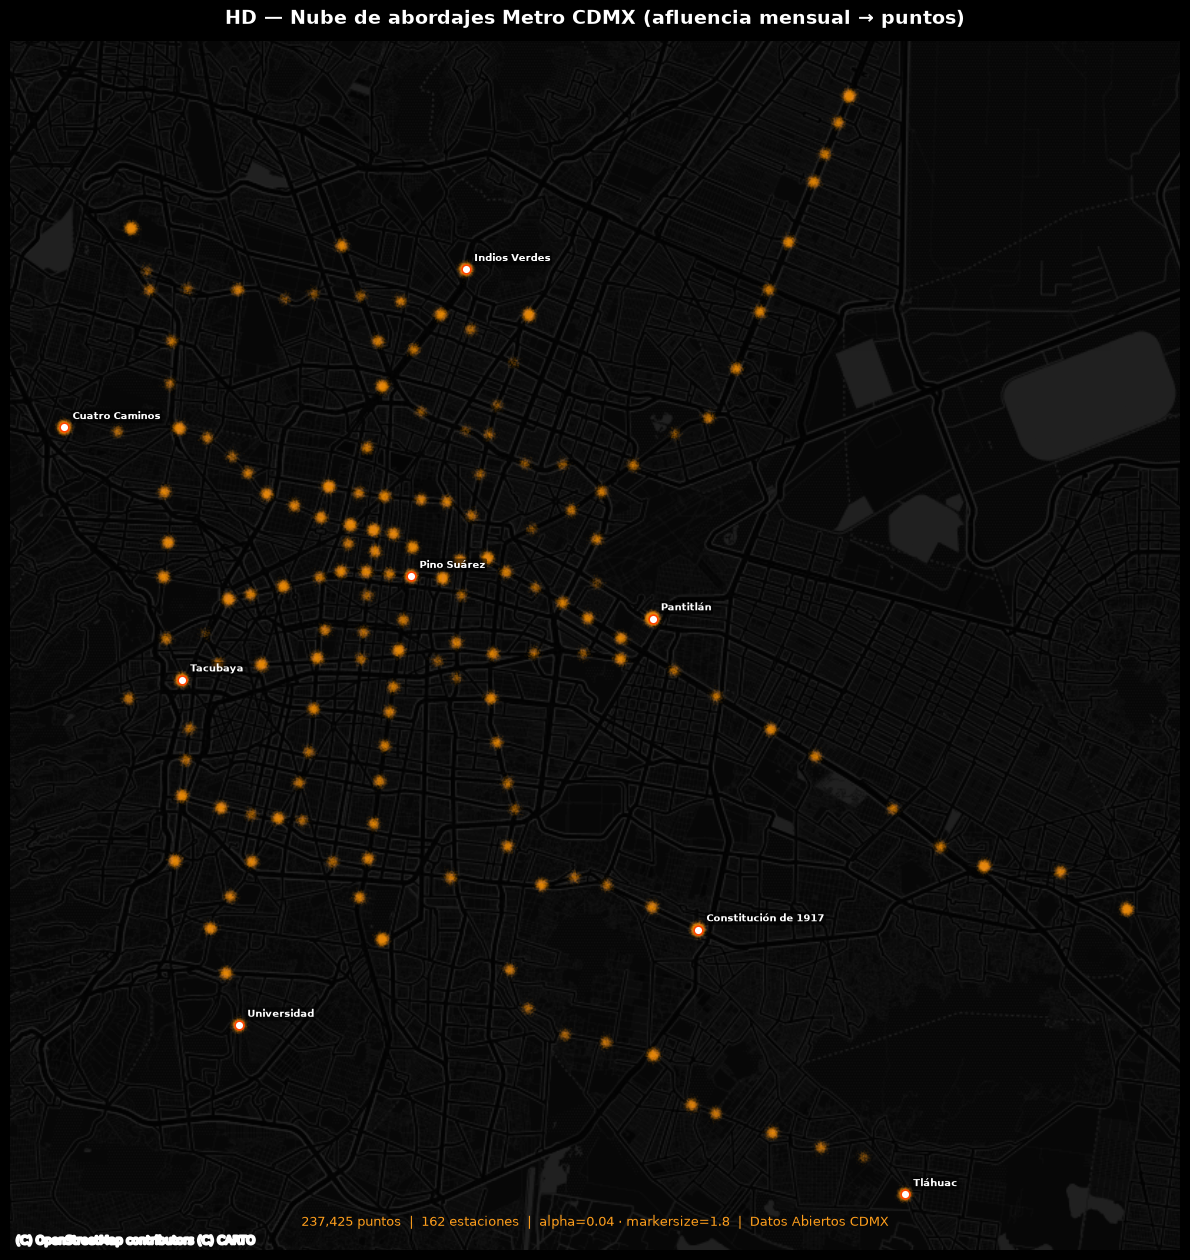

Guardado: Dia8_HD_Scatter.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 13))
fig.patch.set_facecolor('black')

margin = 0.04
dx, dy = maxx - minx, maxy - miny
ax.set_xlim(minx - dx * margin, maxx + dx * margin)
ax.set_ylim(miny - dy * margin, maxy + dy * margin)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.DarkMatterNoLabels,
        zoom_adjust=0,
        alpha=0.85,
        zorder=1,
    )
except Exception as e:
    print('Basemap:', e)

# HD scatter: miles de puntos casi transparentes
gdf_web.plot(
    ax=ax,
    markersize=1.8,
    color='#FF9F1C',
    alpha=0.04,
    edgecolor='none',
    zorder=2,
)

# Estaciones top como anclas legibles
top = gdf_est.nlargest(8, 'afluencia_mes')
top.plot(ax=ax, markersize=40, color='white', edgecolor='#FF4500', linewidth=1.2, zorder=4)
for _, r in top.iterrows():
    ax.annotate(
        r['NOMBRE'],
        xy=(r.geometry.x, r.geometry.y),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=7,
        color='white',
        fontweight='bold',
        zorder=5,
        bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.55, edgecolor='none'),
    )

ax.set_axis_off()
ax.set_title(
    'HD — Nube de abordajes Metro CDMX (afluencia mensual → puntos)',
    fontsize=14, fontweight='bold', color='white', pad=12
)
ax.text(
    0.5, 0.02,
    f'{len(gdf_web):,} puntos  |  {df["estacion"].nunique()} estaciones  |  '
    f'alpha=0.04 · markersize=1.8  |  Datos Abiertos CDMX',
    transform=ax.transAxes, ha='center', fontsize=9, color='#FF9F1C'
)

plt.tight_layout()
plt.savefig(OUT / 'Dia8_HD_Scatter.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia8_HD_Scatter.png')

### 4. Hexbin — la misma densidad, agregada
Cuando el scatter satura, el hexágono resume sin mentir: cuenta puntos por celda.

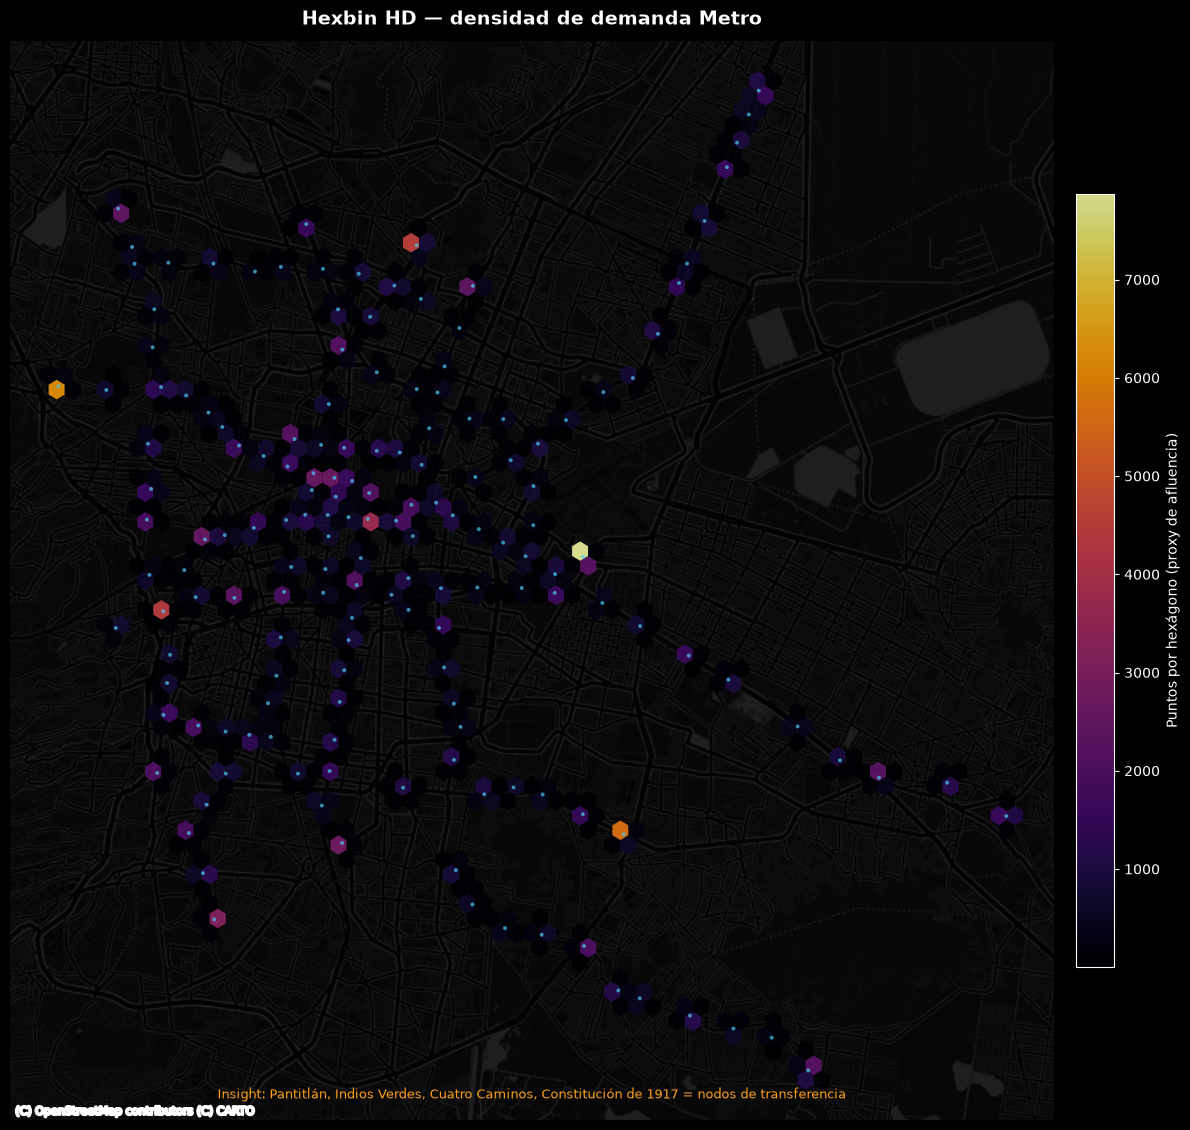

Guardado: Dia8_HD_Hexbin.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 13))
fig.patch.set_facecolor('black')
ax.set_xlim(minx - dx * margin, maxx + dx * margin)
ax.set_ylim(miny - dy * margin, maxy + dy * margin)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom_adjust=0, alpha=0.8, zorder=1)
except Exception:
    pass

hb = ax.hexbin(
    gdf_web.geometry.x,
    gdf_web.geometry.y,
    gridsize=60,
    cmap='inferno',
    mincnt=1,
    linewidths=0,
    alpha=0.85,
    zorder=2,
)
cb = plt.colorbar(hb, ax=ax, fraction=0.035, pad=0.02)
cb.set_label('Puntos por hexágono (proxy de afluencia)', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')

gdf_est.plot(ax=ax, markersize=8, color='#4CC9F0', alpha=0.7, edgecolor='none', zorder=3)

ax.set_axis_off()
ax.set_title('Hexbin HD — densidad de demanda Metro', fontsize=14, fontweight='bold', color='white', pad=12)
ax.text(
    0.5, 0.02,
    'Insight: Pantitlán, Indios Verdes, Cuatro Caminos, Constitución de 1917 = nodos de transferencia',
    transform=ax.transAxes, ha='center', fontsize=9, color='#FF9F1C'
)

plt.tight_layout()
plt.savefig(OUT / 'Dia8_HD_Hexbin.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia8_HD_Hexbin.png')

### 5. Ranking de presión — simbología de estaciones
Las estaciones como burbujas escaladas por afluencia mensual (capa vectorial legible encima del HD).

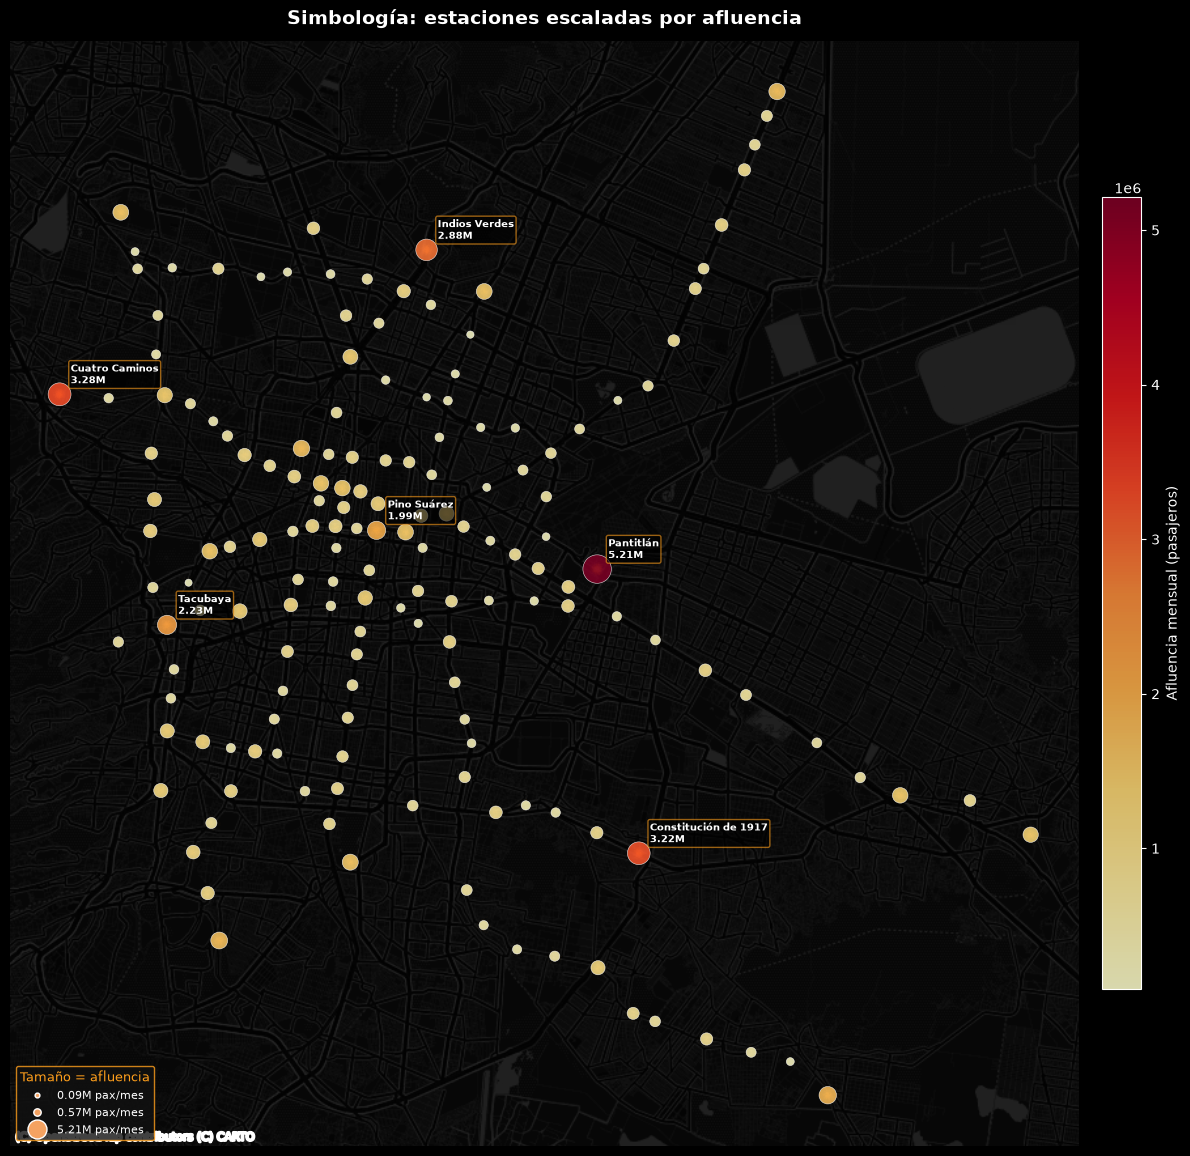

Guardado: Dia8_HD_Simbologia_Estaciones.png


In [6]:
# Tamaño de burbuja proporcional a afluencia
a = gdf_est['afluencia_mes'].astype(float)
sizes = 20 + 400 * (a / a.max())

fig, ax = plt.subplots(figsize=(12, 13))
fig.patch.set_facecolor('black')
ax.set_xlim(minx - dx * margin, maxx + dx * margin)
ax.set_ylim(miny - dy * margin, maxy + dy * margin)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom_adjust=0, alpha=0.85, zorder=1)
except Exception:
    pass

# Fondo HD tenue
gdf_web.sample(min(80_000, len(gdf_web)), random_state=1).plot(
    ax=ax, markersize=1.2, color='#FF9F1C', alpha=0.025, edgecolor='none', zorder=2
)

sc = ax.scatter(
    gdf_est.geometry.x,
    gdf_est.geometry.y,
    s=sizes,
    c=gdf_est['afluencia_mes'],
    cmap='YlOrRd',
    alpha=0.85,
    edgecolors='white',
    linewidths=0.4,
    zorder=4,
)
cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
cb.set_label('Afluencia mensual (pasajeros)', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')

for _, r in gdf_est.nlargest(6, 'afluencia_mes').iterrows():
    ax.annotate(
        f"{r['NOMBRE']}\n{r['afluencia_mes']/1e6:.2f}M",
        xy=(r.geometry.x, r.geometry.y),
        xytext=(8, 8), textcoords='offset points',
        fontsize=7, color='white', fontweight='bold', zorder=5,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6, edgecolor='#FF9F1C'),
    )

ax.set_axis_off()
ax.set_title('Simbología: estaciones escaladas por afluencia', fontsize=14, fontweight='bold', color='white', pad=12)

# Leyenda manual de tamaños
from matplotlib.lines import Line2D
legend_sizes = [a.min(), a.median(), a.max()]
legend_ms = [20 + 400 * (v / a.max()) for v in legend_sizes]
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F4A261', markersize=np.sqrt(ms)/1.5,
           label=f'{v/1e6:.2f}M pax/mes', linestyle='None')
    for v, ms in zip(legend_sizes, legend_ms)
]
leg = ax.legend(handles=handles, loc='lower left', title='Tamaño = afluencia',
                facecolor='#111', edgecolor='#FF9F1C', labelcolor='white', fontsize=8, title_fontsize=9)
leg.get_title().set_color('#FF9F1C')

plt.tight_layout()
plt.savefig(OUT / 'Dia8_HD_Simbologia_Estaciones.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia8_HD_Simbologia_Estaciones.png')

### 6. Panel resumen

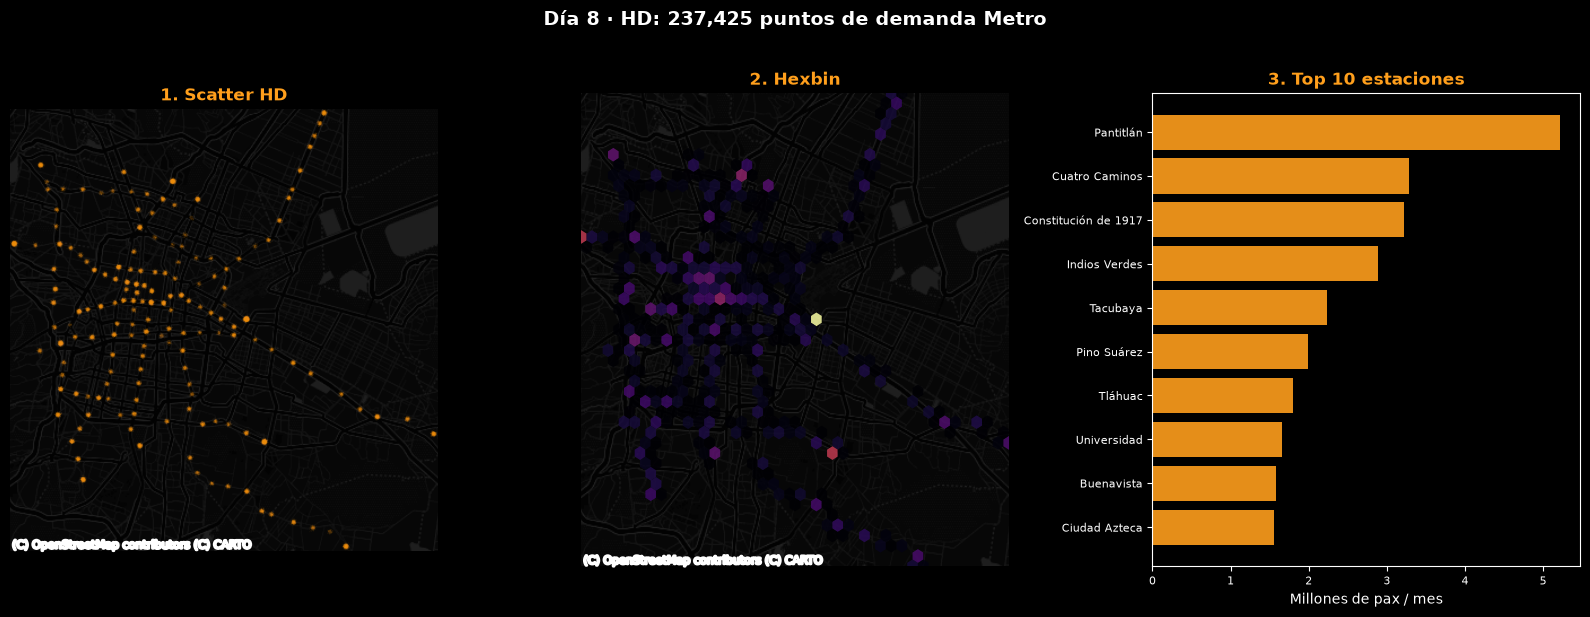

Guardado: Dia8_HD_Panel.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('black')

# 1 scatter
ax = axes[0]
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom_adjust=-1, alpha=0.8, zorder=1)
except Exception:
    pass
gdf_web.sample(min(60_000, len(gdf_web)), random_state=2).plot(ax=ax, markersize=1, color='#FF9F1C', alpha=0.05, edgecolor='none', zorder=2)
ax.set_axis_off(); ax.set_title('1. Scatter HD', color='#FF9F1C', fontweight='bold')

# 2 hexbin
ax = axes[1]
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom_adjust=-1, alpha=0.8, zorder=1)
except Exception:
    pass
ax.hexbin(gdf_web.geometry.x, gdf_web.geometry.y, gridsize=40, cmap='inferno', mincnt=1, linewidths=0, alpha=0.85, zorder=2)
ax.set_axis_off(); ax.set_title('2. Hexbin', color='#FF9F1C', fontweight='bold')

# 3 barras top
ax = axes[2]
top10 = est.nlargest(10, 'afluencia_mes').sort_values('afluencia_mes')
ax.barh(top10['NOMBRE'], top10['afluencia_mes'] / 1e6, color='#FF9F1C', alpha=0.9)
ax.set_xlabel('Millones de pax / mes', color='white')
ax.tick_params(colors='white', labelsize=8)
ax.set_title('3. Top 10 estaciones', color='#FF9F1C', fontweight='bold')
ax.set_facecolor('black')

fig.suptitle(
    f'Día 8 · HD: {len(df):,} puntos de demanda Metro',
    fontsize=14, fontweight='bold', color='white', y=1.02
)
plt.tight_layout()
plt.savefig(OUT / 'Dia8_HD_Panel.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia8_HD_Panel.png')

### 7. Insight de negocio
Un mapa HD de transporte no es arte: es **diagnóstico de capacidad**.

- Los nodos más densos (Pantitlán, Indios Verdes, Cuatro Caminos…) son cuellos de transferencia y anclas de retail / last-mile.
- La nube revela corredores de presión que una tabla de Excel no comunica.
- Técnica: cuando tienes >100k puntos, **alpha + tamaño** (o hexbin) son el toolkit mínimo antes de subir a Datashader/Kepler.

### Regenerar la nube
```bash
python ../00_Datos/descargarDatosHD.py
```

In [8]:
print('Día 8 completado.')
print(f'Puntos renderizados: {len(df):,}')
print(f'Estaciones: {df["estacion"].nunique()}')

Día 8 completado.
Puntos renderizados: 237,425
Estaciones: 162
